# High resolution total alkalinity estimation using GLODAP2

In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib import pyplot as plt
from scipy.special import huber
from sklearn import metrics

import highres_ta as ta

In [4]:
def scoring(y_true, y_pred) -> pd.DataFrame:
    from loguru import logger
    residuals = y_pred - y_true
    scores = pd.Series(
        {
            "root_mean_squared_error": metrics.root_mean_squared_error(y_true, y_pred),
            "mean_absolute_error": metrics.mean_absolute_error(y_true, y_pred),
            "huber_loss": huber(1.35, residuals).mean(),
            "median_absolute_error": metrics.median_absolute_error(y_true, y_pred),
            "mean_bias": residuals.mean(),
            "median_bias": residuals.median(),
            "r2_score": metrics.r2_score(y_true, y_pred),
        },
    name='Scores').to_frame()
    scores.index.name = "Metric"

    logger.info(f"\n{scores.to_markdown(floatfmt='.3f')}")

    return scores

# Model data

In [5]:
model = ta.QuantileRegressionEnsemble.load("../models/quantile_ensemble/models/quantile_ensemble.joblib")
model.optimise_cpus(max_cpus=84)
model.aggregation = "mean"

In [19]:
raw = ta.open_gridded_data()
x_names = tuple(model.estimators[0].feature_names)
features_ds = ta.open_inference_data(x_names)

In [20]:
yhat_ds = ta.predict_map_for_date(model, features_ds, date="2004-01-01")

In [62]:
ice = raw.seaice_fraction_cci.sel(time=yhat_ds.time.values).squeeze()
ice_mask = ice.fillna(0) < 0.15

q50 = yhat_ds.talk_pred.sel(quantile=0.5).squeeze().where(ice_mask)
iqr = (
    yhat_ds.talk_pred.sel(quantile=[0.75, 0.25]).diff(dim="quantile")
    .squeeze()
    .where(ice_mask)
    .pipe(abs)
    .pipe(lambda x: x / 1.349)
)
dq90 = (
    yhat_ds.talk_pred
    .sel(quantile=[0.95, 0.05])
    .diff(dim="quantile")
    .squeeze()
    .where(ice_mask)
    .pipe(abs)
    .pipe(lambda x: x / 3.3)
    .clip(min=1,)
)
std = yhat_ds.talk_pred_q70.sel(quantile=0.5).squeeze().where(ice_mask)

custom = xr.concat([dq90, std, iqr], dim="a").mean(dim="a")
custom_max = custom.max()
custom_min = custom.min()
custom01 = custom.pipe(lambda x: (x - custom_min) / (custom_max - custom_min))
new_min = 2.5
custom = custom01.pipe(lambda x: x * (custom_max - new_min) + new_min)

[None, None, None, None]

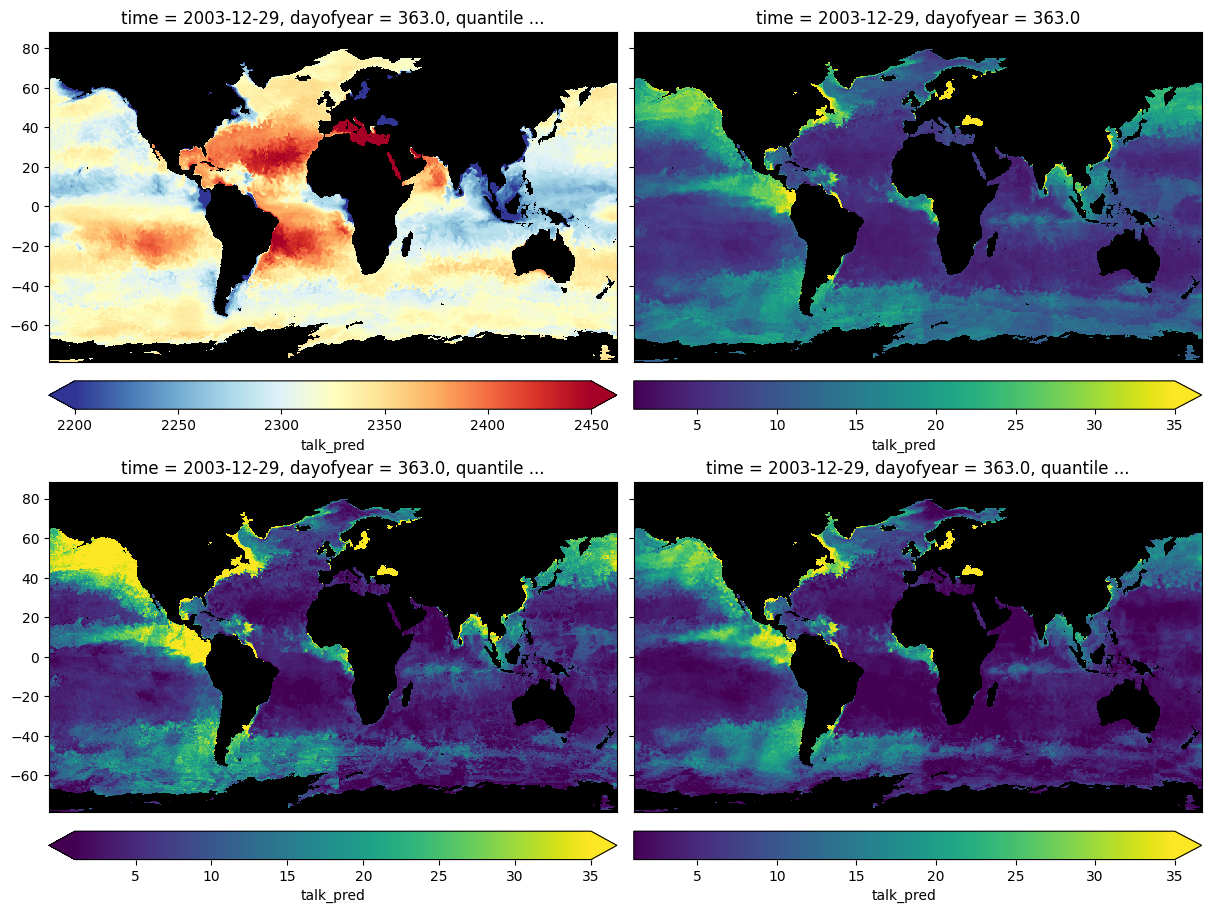

In [64]:
fig, axs = plt.subplots(2, 2, figsize=(12, 9), sharey=True, constrained_layout=True)
axs = axs.flatten()

props = {"robust": True, "cbar_kwargs": {"orientation": 'horizontal'}, "vmin": 1, "vmax": 35}
q50.plot.imshow(ax=axs[0], **(props | {"cmap": "RdYlBu_r", "vmin": 2200, "vmax": 2450}))
custom.plot.imshow(ax=axs[1], **props)
iqr.plot.imshow(ax=axs[2], **props)
dq90.plot.imshow(ax=axs[3], **props)

[ax.set_ylabel("") for ax in axs]
[ax.set_xlabel("") for ax in axs]
[ax.set_xticks([]) for ax in axs]
[ax.set_facecolor("k") for ax in axs]